# Multiclass Classification with CNN on MNIST
**Author:** @VedantAndhale

In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

try:
    tf.config.optimizer.set_jit(False)
except Exception:
    pass

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

2025-04-24 13:52:15.890786: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-24 13:52:15.923974: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745482935.963688   58270 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745482935.975524   58270 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745482936.004114   58270 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## 1. Load and Preprocess the Data

In [3]:
# Load MNIST data
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Normalize images
train_images, test_images = train_images / 255.0, test_images / 255.0

# Reshape images to (28, 28, 1)
train_images = train_images.reshape((-1, 28, 28, 1))
test_images = test_images.reshape((-1, 28, 28, 1))

# One-hot encode labels
train_labels = tf.keras.utils.to_categorical(train_labels, 10)
test_labels = tf.keras.utils.to_categorical(test_labels, 10)

## 2. Define the CNN Model

In [4]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation="relu"))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation="relu"))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation="relu"))
model.add(layers.Dense(10, activation="softmax"))

/home/codelab/dev/practical/CL1/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-04-24 13:52:22.424888: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-04-24 13:52:22.424967: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:167] env: CUDA_VISIBLE_DEVICES="-1"
2025-04-24 13:52:22.424983: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:170] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
2025-04-24 13:52:22.424993: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:178] verbose loggin

## 3. Compile and Train the Model

In [5]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

history = model.fit(
    train_images, train_labels, epochs=3, validation_data=(test_images, test_labels)
)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - accuracy: 0.8976 - loss: 0.3284 - val_accuracy: 0.9860 - val_loss: 0.0420
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9846 - loss: 0.0505 - val_accuracy: 0.9905 - val_loss: 0.0308
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9887 - loss: 0.0340 - val_accuracy: 0.9909 - val_loss: 0.0264


## 4. Evaluate the Model with a Confusion Matrix

In [6]:
# Predict class probabilities
predictions = model.predict(test_images)

# Convert probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(test_labels, axis=1)

# Compute confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)
print("Confusion Matrix:")
print(conf_matrix)

# Calculate accuracy
accuracy = np.sum(predicted_labels == true_labels) / len(true_labels)
print(f"Accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Confusion Matrix:
[[ 976    1    0    0    0    0    1    1    1    0]
 [   0 1131    1    1    0    0    0    0    2    0]
 [   1    1 1024    0    1    0    3    2    0    0]
 [   0    0    3 1005    0    2    0    0    0    0]
 [   0    0    0    0  977    0    2    0    0    3]
 [   1    0    0    9    0  878    3    0    0    1]
 [   4    2    0    1    1    2  947    0    1    0]
 [   0    4    3    1    0    1    0 1013    0    6]
 [   3    0    2    1    1    0    0    1  964    2]
 [   1    0    0    1    3    6    0    0    4  994]]
Accuracy: 0.9909


## 5. Visualize the Confusion Matrix

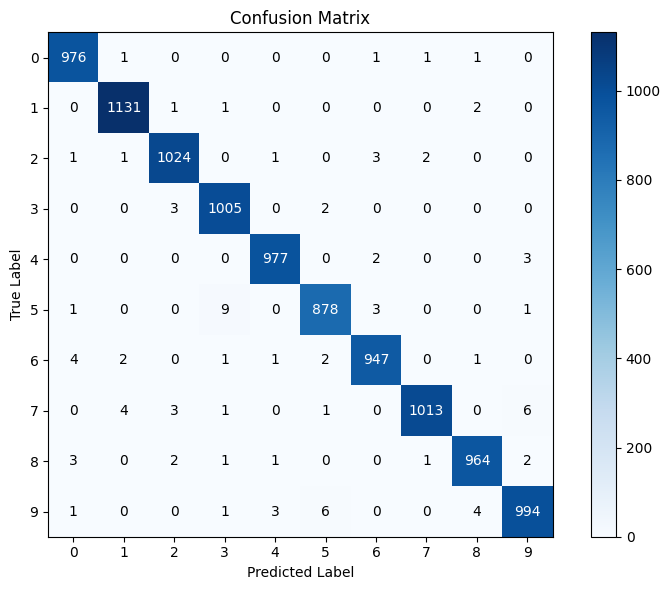

In [7]:
plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(conf_matrix.shape[0])
plt.xticks(tick_marks, tick_marks)
plt.yticks(tick_marks, tick_marks)

thresh = conf_matrix.max() / 2.0
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(
            j,
            i,
            format(conf_matrix[i, j], "d"),
            ha="center",
            va="center",
            color="white" if conf_matrix[i, j] > thresh else "black",
        )

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()